<div style="background-color: #e6f2ff; border-radius: 15px; padding: 30px; margin: 20px auto; width: 90%; max-width: 90%; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1);">
    <h5 style="color: #004e98; font-size: 26px; font-weight: bold;">Taller: </h5>
    <h5 style="color: #004e98; font-size: 26px;">Regresión Lineal Múltiple</h5>
    <h5 style="color: #2a4d7f; font-size: 20px;">Marcelo Chávez</h5>
<div style="text-align: left;">
    <span style="color:rgb(237, 244, 248); font-size: 18px;">Marcelo Chávez</span>
<br> 
<a href="https://github.com/marcelochavez-ec/marcelochavez-ec" target="_blank">
    <img src="https://upload.wikimedia.org/wikipedia/commons/9/91/Octicons-mark-github.svg" alt="GitHub Logo" width="40px" style="margin-right: 10px;">
</a>
<a href="https://www.linkedin.com/in/marcelochavezec/" target="_blank">
    <img src="https://upload.wikimedia.org/wikipedia/commons/0/01/LinkedIn_Logo.svg" alt="LinkedIn Logo" width="90px">
</a>
</div>

In [1]:
import pyreadstat
import os
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
# Cambiar el directorio de trabajo
os.chdir("D:/DATA_SCIENCE_ENDI")

In [2]:
# Cargar el archivo SPSS
df_tabaco, meta_tabaco = pyreadstat.read_sav("NOTEBOOKS_PYTHON/MULTIVARIANTE_I/DATASETS/MUESTRA_CONSUMO_TABACO_GUAYAQUIL.sav")
df_tabaco.shape

(25, 6)

In [3]:
display(df_tabaco)

,CLASE,ALQUITRAN,NICOTINA,PESO,MONOXIDO_CARBONO,TIPOTA_BACO
0,RUBIO,4.1,0.86,0.9853,13.6,2.0
1,NEGRO,16.0,1.06,1.0938,16.6,1.0
2,NEGRO,29.8,2.03,1.1650,23.5,1.0
3,RUBIO,8.0,0.67,0.9280,10.2,2.0
4,RUBIO,4.1,0.40,0.9462,5.4,2.0
5,NEGRO,15.0,1.04,0.8885,15.0,1.0
6,RUBIO,8.8,0.75,1.0267,9.0,2.0
7,RUBIO,12.4,0.95,0.9225,12.3,2.0
8,NEGRO,16.6,1.12,0.9372,16.3,1.0
9,RUBIO,14.9,1.02,0.8858,15.4,2.0


In [4]:
# Definir variables
X = df_tabaco['ALQUITRAN']  # Variable independiente
y = df_tabaco['MONOXIDO_CARBONO']  # Variable dependiente

# Agregar constante para el intercepto (beta0)
X = sm.add_constant(X)

In [7]:
# Ajustar modelo de regresión lineal
modelo = sm.OLS(y, X).fit()

# Mostrar resumen del modelo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:       MONOXIDO_CARBONO   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     106.9
Date:                Sun, 30 Mar 2025   Prob (F-statistic):           4.07e-10
Time:                        20:51:33   Log-Likelihood:                -52.224
No. Observations:                  25   AIC:                             108.4
Df Residuals:                      23   BIC:                             110.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8825      0.930      4.174      0.0

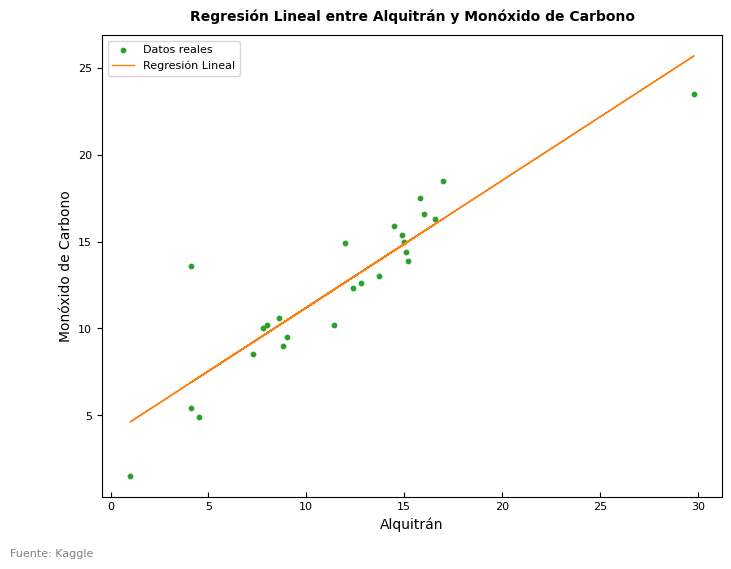

In [9]:
# Predicciones del modelo
y_pred = modelo.predict(X)

# Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(8, 6))

# Graficar los datos y la línea de regresión con nueva paleta de colores
ax.scatter(df_tabaco['ALQUITRAN'], y, color="#2ca02c", label="Datos reales", s=10)  # Verde
ax.plot(df_tabaco['ALQUITRAN'], y_pred, color="#ff7f0e", label="Regresión Lineal", linewidth=1)  # Naranja

# Configurar etiquetas y título
ax.set_xlabel("Alquitrán", fontsize=10)
ax.set_ylabel("Monóxido de Carbono", fontsize=10)
ax.set_title("Regresión Lineal entre Alquitrán y Monóxido de Carbono", 
             fontsize=10, fontweight="bold", loc="center", pad=10)  # Espacio extra con `pad`

# Ajustes de ticks
ax.tick_params(axis="x", direction="in", labelsize=8)
ax.tick_params(axis="y", labelsize=8)

# Agregar leyenda
ax.legend(fontsize=8)

# Agregar footnote alineado a la izquierda
fig.text(0.01, 0.01, "Fuente: Kaggle", fontsize=8, color="gray", ha="left")

# Mostrar la gráfica
plt.show()

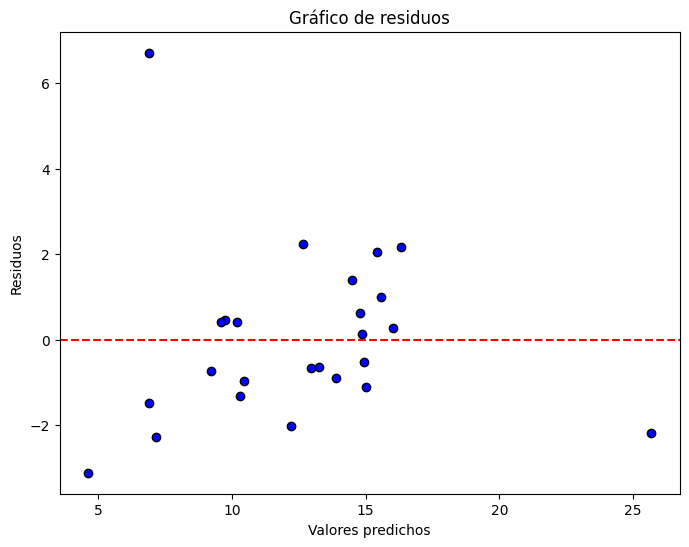

In [10]:
# Obtener los valores predichos (ajustados) y los residuos
y_pred = modelo.predict(X)
residuos = modelo.resid

# Graficar los residuos vs. los valores predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuos, color='blue', edgecolor='black')
plt.axhline(0, color='red', linestyle='--')  # Línea horizontal en 0
plt.title('Gráfico de residuos')
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.show()

# Interpretación de los Resultados de la Regresión OLS

## 1. Evaluación General del Modelo

- **R-squared (R²) = 0.823**  
  Esto indica que el modelo explica el **82.3%** de la variabilidad en la variable dependiente (`MONOXIDO_CARBONO`). Un valor de R² alto sugiere que el predictor `ALQUITRAN` es un buen explicador de la variabilidad en `MONOXIDO_CARBONO`.

- **Adj. R-squared = 0.815**  
  El R² ajustado tiene en cuenta el número de predictores en el modelo. Este valor indica que el modelo no está sobreajustado, ya que no disminuye significativamente con respecto al R².

## 2. Significancia del Modelo

- **F-statistic = 106.9, Prob (F-statistic) = 4.07e-10**  
  Un valor de F alto y un p-valor extremadamente bajo (**< 0.05**) indican que el modelo es **globalmente significativo**. Es decir, la relación entre `ALQUITRAN` y `MONOXIDO_CARBONO` es real y no debida al azar.

## 3. Interpretación de los Coeficientes

| Variable   | Coeficiente | Std. Error | t-valor | p-valor | IC 95% (Límite Inferior - Superior) |
|------------|-------------|------------|---------|---------|------------------------------------|
| **Constante** (intercepto) | 3.8825 | 0.930 | 4.174 | **0.000** | [1.958, 5.807] |
| **ALQUITRAN** | **0.7317** | 0.071 | **10.338** | **0.000** | [0.585, 0.878] |

### Interpretación de los Coeficientes:

- **Intercepto (3.8825)**  
  Cuando `ALQUITRAN = 0`, el nivel estimado de `MONOXIDO_CARBONO` es **3.88**. Esto indica el valor de `MONOXIDO_CARBONO` cuando no hay presencia de alquitrán.

- **Coeficiente de ALQUITRAN (0.7317)**  
  Por cada **unidad adicional** de `ALQUITRAN`, el `MONOXIDO_CARBONO` aumenta en **0.7317 unidades**, manteniendo todo lo demás constante. Este es el impacto directo de `ALQUITRAN` sobre el monóxido de carbono.

- **p-valores (< 0.05)**  
  Ambos coeficientes tienen p-valores **muy cercanos a 0**, lo que indica que son **estadísticamente significativos**.

## 4. Evaluación de Supuestos

- **Durbin-Watson = 1.779**  
  El valor de Durbin-Watson sugiere que hay **ligera autocorrelación** en los residuos, pero no es una preocupación grave.

- **Omnibus Prob = 0.000 y Jarque-Bera Prob = 5.65e-05**  
  Estos resultados indican que los residuos **no siguen una distribución normal**. Esto puede afectar la validez de algunas inferencias, por lo que es recomendable realizar pruebas adicionales o aplicar transformaciones si fuera necesario.

- **Skew = 1.433 y Kurtosis = 6.251**  
  La **asimetría positiva** y las **colas pesadas** en la distribución de los residuos sugieren que los datos no se ajustan completamente a una distribución normal.

- **Cond. No. (30.1)**  
  Este valor no indica colinealidad grave en los predictores, lo que significa que no hay problemas evidentes de multicolinealidad en el modelo.

## 5. Conclusión

- El modelo de regresión es **estadísticamente significativo** y explica **el 82.3%** de la variabilidad de la variable `MONOXIDO_CARBONO` con respecto a `ALQUITRAN`.
- **El alquitrán tiene un efecto positivo y significativo** en la concentración de monóxido de carbono.
- Sin embargo, los **residuos no siguen completamente una distribución normal**, lo que podría afectar la validez de algunas inferencias. Se recomienda realizar pruebas adicionales, como la transformación de variables o la inclusión de más predictores, si fuera necesario.

---

El valor de $R^{2}$ es de **0.82** lo que indica que si conocemos el contenido de _*Alquitrán*_ de un cigarrillo, podemos mejorar en un **82%** nuestros pronósticos sobre el contenido en _*Monóxido de Carbono*_; es decir, si en lugar de utilizar como pronóstico el valor medio del contenido en _*Monóxido*_, basamos nuestro pronóstico en el contenido de Alquitrán, mejora la estimación en un **82%**.

* Si el contenido de Alquitrán de los cigarrillos fuees 0mg, cabría esperar una cantidad de Monóxido de Carbono de 3.88mg
* Por cada incremento en 1mg en el contenido de Alquitrán cabe esperar que la cantidad de Monóxido de Carbono producido se incremente en 0.73mg